# Model Evaluation — In-Depth Analysis
**Notebook 06 — IDX Exchange Data Science Internship 2026**

This notebook provides an in-depth evaluation of the final XGBoost model beyond 
our evaluation metrics. Performance is analyzed by price band, school district, and 
bedroom count to identify where the model excels and where it struggles.

**Input:** `train_enriched.csv` and `test_enriched.csv` from Notebook 04  
**Output:** `metrics_summary.csv`, `price_band_metrics.csv`, saved model files (`xgb_model.pkl`)

## Evaluation Metrics

Beyond R², the following percentage-based metrics are used to evaluate model performance. 
Percentage-based metrics are especially appropriate for real estate because dollar errors 
have different significance at different price levels, 20,000 dollars off is negligible 
on a 2 million dollar home but significant on a 200,000 dollar home.

### MAPE — Mean Absolute Percentage Error

$$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

The average percentage error across all predictions. Intuitive but sensitive to outliers — 
a single very wrong prediction on a low-priced property can pull the mean up significantly.

### MdAPE — Median Absolute Percentage Error

$$MdAPE = \text{median}\left( \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100 \right)$$

The middle value of all percentage errors. Robust to outliers and represents the 
typical prediction error — the primary metric used throughout this project.
A MdAPE of 7.66% means the model predicts a typical California single-family 
home's sale price within 7.66% of the actual value.

Where:
- $y_i$ = actual ClosePrice
- $\hat{y}_i$ = predicted ClosePrice
- $n$ = number of properties in the test set

In [5]:
# imports and best model predictions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import re

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"

#util funcitons
def make_train_test_split(df, date_col='CloseDate', x_months=12):
    """
    Creates a time-based train/test split.
    
    Parameters:
        df: cleaned dataframe
        date_col: name of the date column to split on
        x_months: number of months to use for training window (tunable)
    
    Returns:
        train_df, test_df
    """
    df[date_col] = pd.to_datetime(df[date_col], format='mixed')
    
    latest_month = df[date_col].dt.to_period('M').max()
    cutoff_month = latest_month - x_months
    
    test_df = df[df[date_col].dt.to_period('M') == latest_month].copy()
    train_df = df[
        (df[date_col].dt.to_period('M') > cutoff_month) &
        (df[date_col].dt.to_period('M') < latest_month)
    ].copy()
    
    print(f"Test month: {latest_month}")
    print(f"Training window: {x_months} months ({cutoff_month} to {latest_month})")
    print(f"Training rows: {len(train_df):,}")
    print(f"Testing rows:  {len(test_df):,}")
    
    return train_df, test_df

def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

# metrics function
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse,
            "MAE": mae, "MAPE": mape, "MdAPE": mdape}

## 1. Data Loading & Model Retraining

The enriched dataset is reloaded and the final XGBoost model is retrained using 
the same three-way chronological split and parameters established in Notebook 05.
This ensures all evaluation metrics in this notebook are consistent with the 
final production model.

In [12]:
# updating test/train split

train_full = pd.read_csv(filepath + r"\train_enriched.csv", low_memory=False)
train_df, test_df = make_train_test_split(train_full, x_months=30)

val_month = train_df["CloseDate"].dt.to_period("M").max()
val_df = train_df[train_df["CloseDate"].dt.to_period("M") == val_month].copy()
train_df = train_df[train_df["CloseDate"].dt.to_period("M") < val_month].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Test month: 2026-05
Training window: 30 months (2023-11 to 2026-05)
Training rows: 303,839
Testing rows:  11,844
Train: 292,001 rows
Val:   11,838 rows
Test:  11,844 rows


In [14]:
# rerunning XGB

# build features
drop_cols = [                                                          # ensuring that leakage variables are dropped
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket",
    "HighSchoolDistrict", "DistrictName", "DistrictMedianPrice",
    "Latitude_orig", "Longitude_orig"
]

x_train_v = train_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")       #_v added for validation set clarification
x_val_v   = val_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_test_v  = test_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
y_train_v = train_df["ClosePrice"]
y_val_v   = val_df["ClosePrice"]
y_test_v  = test_df["ClosePrice"]

print(f"X_train: {x_train_v.shape}")
print(f"X_val:   {x_val_v.shape}")
print(f"X_test:  {x_test_v.shape}")

x_train_v = clean_col_names(x_train_v)
x_val_v   = clean_col_names(x_val_v)
x_test_v  = clean_col_names(x_test_v)

# retraining final XGBoost (best method as seen last week)
xgb_final = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=11,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    x_train_v, y_train_v,
    eval_set=[(x_val_v, y_val_v)],
    verbose=False
)

y_pred_xgb_final = xgb_final.predict(x_test_v)
print(f"Done — best trees: {xgb_final.best_iteration}")

X_train: (292001, 52)
X_val:   (11838, 52)
X_test:  (11844, 52)
Done — best trees: 916


## 2. Price Band Analysis

California's real estate market spans a wide price range, from sub-500k entry 
level homes to multi-million dollar luxury properties. Rather than using statistical 
quintiles, price bands are defined based on meaningful California market segments:

| Band | Range | Share of Test Set |
|---|---|---|
| Entry | Under 500k | 13.7% |
| Mid | 500k – 750k | 21.3% |
| Upper Mid | 750k – 1M | 20.0% |
| Luxury | 1M – 2M | 31.6% |
| Ultra Luxury | Over 2M | 13.3% |

Analyzing these price bands reveal where the model is the most and least reliable.

In [21]:
# evaluation dataframe with custom price bands
eval_df = pd.DataFrame({
    "ActualPrice": y_test_v.values,
    "PredictedPrice": y_pred_xgb_final
})

eval_df["APE"] = np.abs(
    (eval_df["ActualPrice"] - eval_df["PredictedPrice"]) / eval_df["ActualPrice"]
) * 100

eval_df["AbsError"] = np.abs(eval_df["ActualPrice"] - eval_df["PredictedPrice"])

# custom price bands reflecting CA market distribution
bins = [0, 500000, 750000, 1000000, 2000000, float("inf")]
labels = ["Entry\n<$500k", "Mid\n$500k-$750k", "Upper Mid\n$750k-$1M", "Luxury\n$1M-$2M", "Ultra Luxury\n>$2M"]

eval_df["PriceBand"] = pd.cut(eval_df["ActualPrice"], bins=bins, labels=labels)

# metrics per band
band_metrics = eval_df.groupby("PriceBand", observed=True).agg(
    Count=("ActualPrice", "count"),
    MedianPrice=("ActualPrice", "median"),
    MdAPE=("APE", "median"),
    MAPE=("APE", "mean"),
    MAE=("AbsError", "mean")
).round(2)

band_metrics["MAE"] = band_metrics["MAE"].map("${:,.0f}".format)
band_metrics["MedianPrice"] = band_metrics["MedianPrice"].map("${:,.0f}".format)

print(band_metrics)

                      Count MedianPrice  MdAPE   MAPE       MAE
PriceBand                                                      
Entry\n<$500k          1626    $409,950   8.00  14.14   $52,635
Mid\n$500k-$750k       2526    $634,400   6.29   9.69   $61,136
Upper Mid\n$750k-$1M   2372    $865,000   6.58   9.28   $81,267
Luxury\n$1M-$2M        3744  $1,365,000   8.62  11.28  $160,389
Ultra Luxury\n>$2M     1576  $2,791,500  11.25  14.15  $457,827


## 3. Price Band Performance Charts

The left chart shows MdAPE by price band with the overall MdAPE (red dashed line) 
as a reference. The right chart shows the distribution of test properties across 
price bands — higher counts generally correlate with better model performance 
since more training examples are available for that segment.

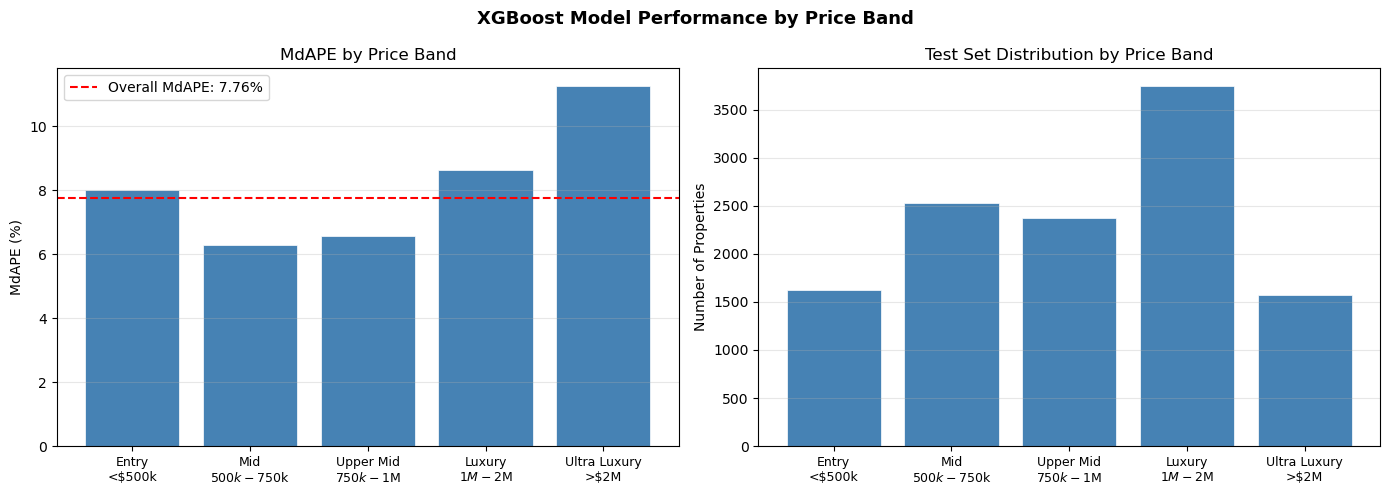

In [24]:
# plotting the model performance by price band 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bands = eval_df.groupby("PriceBand", observed=True)["APE"].median()
counts = eval_df.groupby("PriceBand", observed=True)["ActualPrice"].count()

# MdAPE by price band
axes[0].bar(range(len(bands)), bands.values, 
            color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axhline(y=eval_df["APE"].median(), color="red", linestyle="--",
                label=f"Overall MdAPE: {eval_df['APE'].median():.2f}%")
axes[0].set_xticks(range(len(bands)))
axes[0].set_xticklabels(bands.index, fontsize=9)
axes[0].set_ylabel("MdAPE (%)")
axes[0].set_title("MdAPE by Price Band")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# count by price band
axes[1].bar(range(len(counts)), counts.values,
            color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, fontsize=9)
axes[1].set_ylabel("Number of Properties")
axes[1].set_title("Test Set Distribution by Price Band")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("XGBoost Model Performance by Price Band", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(filepath + r"\mdape_by_price_band.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Geographic Analysis — School District Performance

Model performance is analyzed by school district to identify geographic areas 
where the model is most and least reliable. Only districts with 50+ test 
properties are included to ensure statistically meaningful results.

Districts with more uniform housing stock (consistent lot sizes and home types) 
tend to show lower MdAPE. Districts with high price variance, such as coastal luxury 
markets, mixed urban/rural areas, tend to show higher MdAPE.

Districts with 50+ test samples: 52

Best performing districts:
                         Count  MdAPE  MAPE  MedianPrice
District                                                
Antioch Unified             53   3.61  4.99     600000.0
Fontana Unified             59   4.04  6.24     649000.0
Beaumont Unified            71   4.31  5.28     552750.0
Temecula Valley Unified    150   4.53  6.04     760000.0
Corona-Norco Unified       146   4.71  6.53     880000.0
Moreno Valley Unified       88   4.77  6.46     546500.0
Murrieta Valley Unified     84   4.86  8.37     720000.0
Hesperia Unified            91   5.05  7.19     470000.0
Simi Valley Unified         87   5.10  6.25     900000.0
Chino Valley Unified        78   5.14  7.71     900100.0

Worst performing districts:
                           Count  MdAPE   MAPE  MedianPrice
District                                                   
Mt. Diablo Unified           146   9.88  11.70    1005000.0
West Contra Costa Unified     82  10.15  13

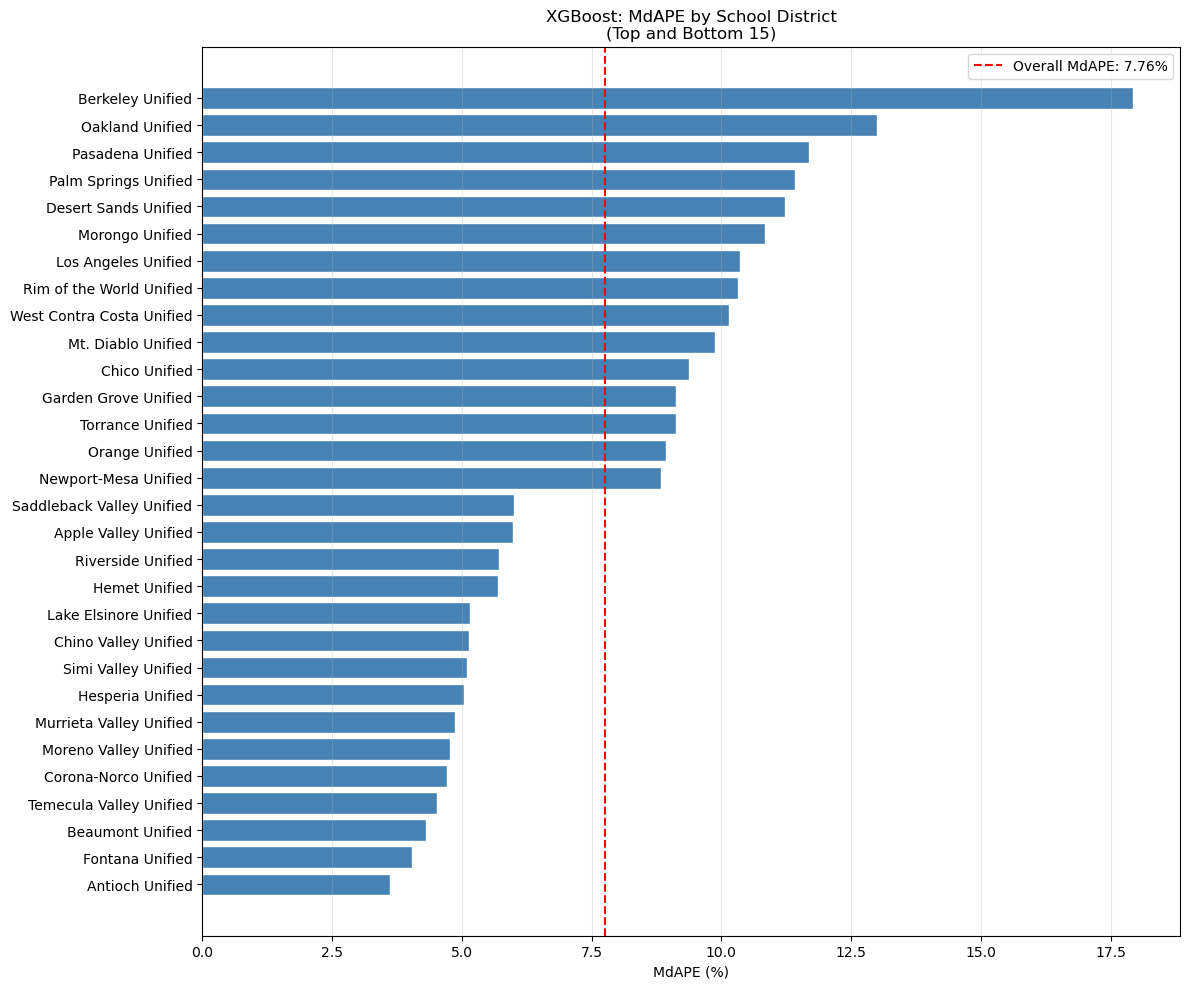

In [27]:
# plotting model error by school district

eval_df["District"] = test_df["DistrictName"].reset_index(drop=True)

district_metrics = eval_df.groupby("District").agg(
    Count=("ActualPrice", "count"),
    MdAPE=("APE", "median"),
    MAPE=("APE", "mean"),
    MedianPrice=("ActualPrice", "median")
).round(2)

# only districts with 50+ samples
district_metrics = district_metrics[district_metrics["Count"] >= 50].sort_values("MdAPE")

print(f"Districts with 50+ test samples: {len(district_metrics)}")
print("\nBest performing districts:")
print(district_metrics.head(10))
print("\nWorst performing districts:")
print(district_metrics.tail(10))

# plot top and bottom 15
plot_df = pd.concat([district_metrics.head(15), district_metrics.tail(15)])

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(plot_df.index, plot_df["MdAPE"], color="steelblue", edgecolor="white")
ax.axvline(x=eval_df["APE"].median(), color="red", linestyle="--",
           label=f"Overall MdAPE: {eval_df['APE'].median():.2f}%")
ax.set_xlabel("MdAPE (%)")
ax.set_title("XGBoost: MdAPE by School District\n(Top and Bottom 15)")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(filepath + r"\mdape_by_district.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Predicted vs Actual Close Price — Colored by Price Band

Each point represents one property in the June 2026 test set. Points close to 
the red diagonal line are accurate predictions. The color coding shows which 
price band each property belongs to, providing a visual on prediction errors by price band segment.

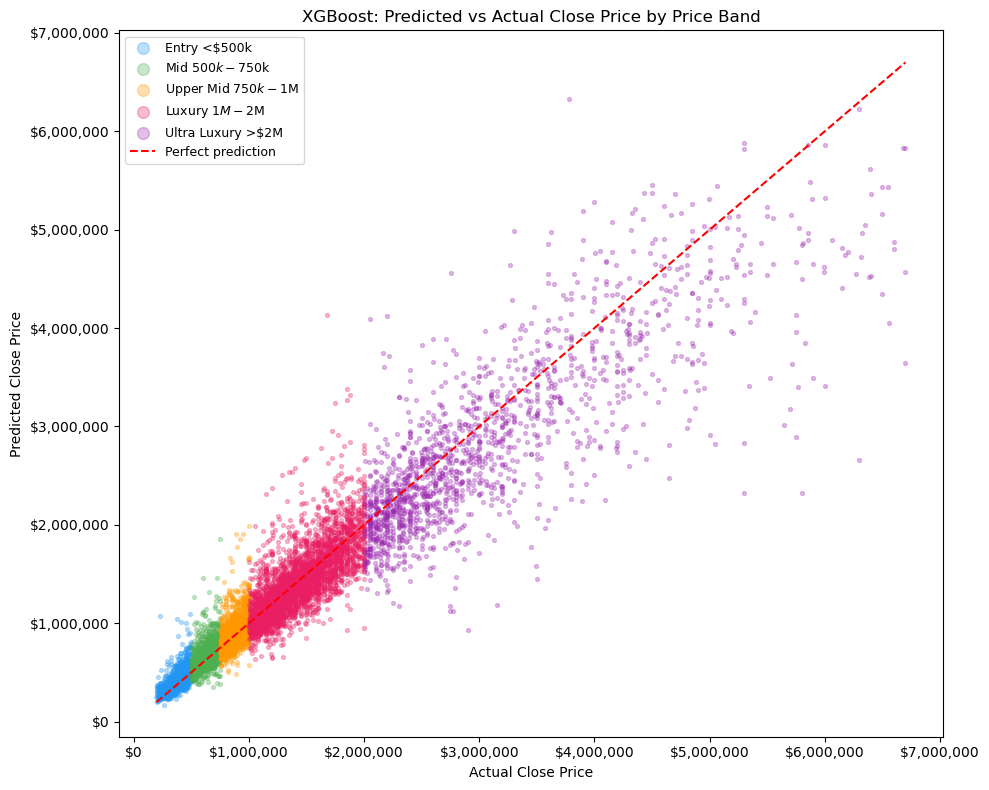

In [32]:
#plotting residuals by price band
fig, ax = plt.subplots(figsize=(10, 8))

colors = {"Entry\n<$500k": "#2196F3", "Mid\n$500k-$750k": "#4CAF50", 
          "Upper Mid\n$750k-$1M": "#FF9800", "Luxury\n$1M-$2M": "#E91E63",
          "Ultra Luxury\n>$2M": "#9C27B0"}

for band, group in eval_df.groupby("PriceBand", observed=True):
    ax.scatter(group["ActualPrice"], group["PredictedPrice"],
               alpha=0.3, s=8, label=band.replace("\n", " "),
               color=colors[band])

ax.plot([y_test_v.min(), y_test_v.max()],
        [y_test_v.min(), y_test_v.max()],
        color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Close Price")
ax.set_ylabel("Predicted Close Price")
ax.set_title("XGBoost: Predicted vs Actual Close Price by Price Band")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig(filepath + r"\predicted_vs_actual_by_band.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. MdAPE Heatmap — Price Band vs Bedroom Count

This heatmap shows MdAPE across two dimensions simultaneously: price band and 
bedroom count. Darker red cells indicate higher prediction error. This reveals 
whether the model struggles with specific combinations of price level and 
property size that a one-dimensional analysis would miss.

Note: BedroomsTotal values are scaled from preprocessing, the bands approximate 
the underlying bedroom counts rather than using exact values.

BedroomBand
1-2 bed    5342
3 bed       200
4 bed        39
5+ bed        8
Name: count, dtype: int64
BedroomBand             1-2 bed      3 bed       4 bed     5+ bed
PriceBand                                                        
Entry\n<$500k          7.312044        NaN  146.606828  20.706832
Mid\n$500k-$750k       5.236081   6.693641   14.564228        NaN
Upper Mid\n$750k-$1M   6.101820   8.935816   11.285063   5.114138
Luxury\n$1M-$2M        7.940838   8.327311   11.808963  20.737044
Ultra Luxury\n>$2M    10.567751  11.826368    9.880524  17.129532


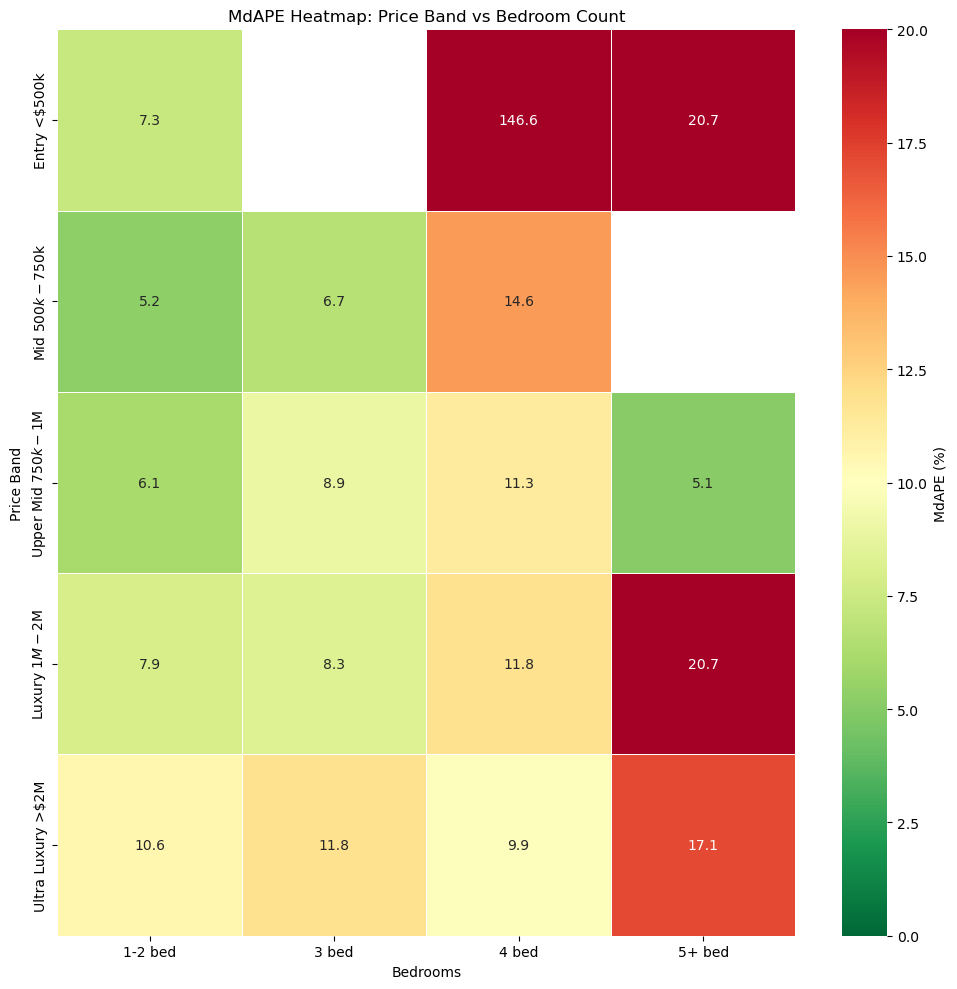

In [39]:
# adding bedrooms from test features

import seaborn as sns
eval_df["Bedrooms"] = x_test_v["BedroomsTotal"].reset_index(drop=True)
eval_df["BedroomBand"] = pd.cut(eval_df["Bedrooms"], bins=[0, 2, 3, 4, 10], labels=["1-2 bed", "3 bed", "4 bed", "5+ bed"])
print(eval_df["BedroomBand"].value_counts())

# rebuild heatmap
heatmap_data = eval_df.groupby(["PriceBand", "BedroomBand"], observed=True)["APE"].median().unstack()
print(heatmap_data)

# plot
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax, linewidths=0.5, cbar_kws={"label": "MdAPE (%)"}, vmin=0, vmax=20, mask=heatmap_data.isna())
ax.set_xlabel("Bedrooms")
ax.set_ylabel("Price Band")
ax.set_title("MdAPE Heatmap: Price Band vs Bedroom Count")
ax.set_yticklabels([t.get_text().replace("\n", " ") for t in ax.get_yticklabels()])
plt.tight_layout()
plt.savefig(filepath + r"\mdape_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Predicted vs Actual Close Price — Colored by Error Magnitude

Each point is colored by its Absolute Percentage Error (APE), capped at 30% 
for visual clarity. Green points are accurate predictions, red points are large 
errors.

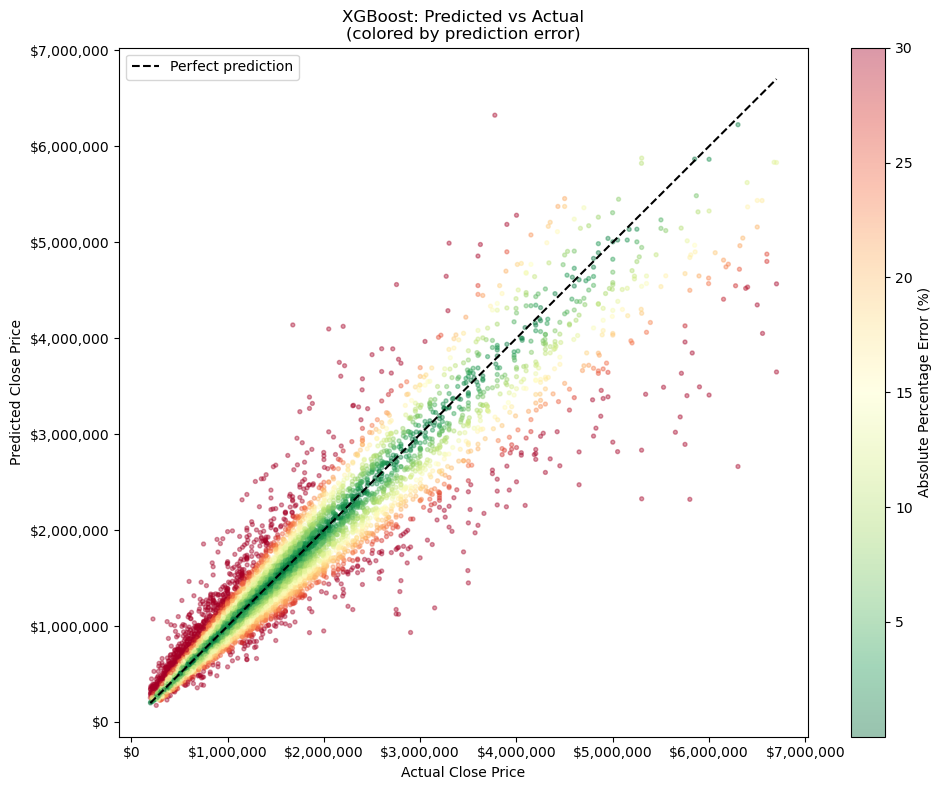

In [44]:
# plotting errors by magnitude
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    eval_df["ActualPrice"], 
    eval_df["PredictedPrice"],
    c=eval_df["APE"].clip(0, 30),  # cap at 30% for color scale
    cmap="RdYlGn_r",
    alpha=0.4,
    s=8
)

ax.plot([y_test_v.min(), y_test_v.max()],
        [y_test_v.min(), y_test_v.max()],
        color="black", linestyle="--", linewidth=1.5, label="Perfect prediction")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Absolute Percentage Error (%)")

ax.set_xlabel("Actual Close Price")
ax.set_ylabel("Predicted Close Price")
ax.set_title("XGBoost: Predicted vs Actual\n(colored by prediction error)")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(filepath + r"\predicted_vs_actual_error.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Overestimate vs Underestimate by Price Band

This chart shows what percentage of predictions in each price band are 
overestimates (predicted > actual) vs underestimates (predicted < actual). 
The black dashed line at 50% represents a perfectly balanced model.

A model that consistently overestimates in one segment and underestimates in 
another has a systematic bias that could inform deployment decisions.

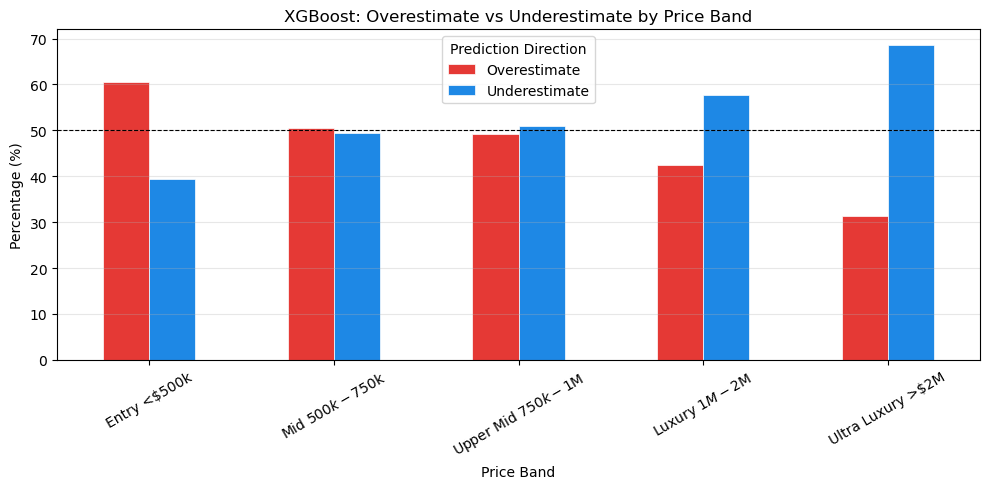

In [48]:
# plotting over and underestimatons by price band
eval_df["Direction"] = np.where(
    eval_df["PredictedPrice"] > eval_df["ActualPrice"], 
    "Overestimate", "Underestimate"
)

direction_by_band = eval_df.groupby(
    ["PriceBand", "Direction"], observed=True
).size().unstack(fill_value=0)

direction_by_band_pct = direction_by_band.div(direction_by_band.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
direction_by_band_pct.plot(kind="bar", ax=ax, 
                            color=["#E53935", "#1E88E5"],
                            edgecolor="white", linewidth=0.5)
ax.axhline(y=50, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Price Band")
ax.set_ylabel("Percentage (%)")
ax.set_title("XGBoost: Overestimate vs Underestimate by Price Band")
ax.set_xticklabels([t.get_text().replace("\n", " ") for t in ax.get_xticklabels()], 
                    rotation=30)
ax.legend(title="Prediction Direction")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(filepath + r"\over_under_estimate.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Evaluation Summary

### Overall Performance
The final XGBoost model achieved an R² of 0.9070 and MdAPE of 7.66% on the 
held-out June 2026 test set, meaning the model predicts a typical California 
single-family home's sale price within 7.66% of the actual value. This represents 
a 22+ percentage point improvement over the Linear Regression baseline (MdAPE 30.42%).

### Performance by Price Band
The model performs best on mid-market properties where training data is most abundant:

- Mid (500k-750k): MdAPE 6.29%, MAPE 9.69%
- Upper Mid (750k-1M): MdAPE 6.58%, MAPE 9.28%
- Entry (under 500k): MdAPE 8.00%, MAPE 14.14%
- Luxury (1M-2M): MdAPE 8.62%, MAPE 11.28%
- Ultra Luxury (over 2M): MdAPE 11.25%, MAPE 14.15%

The gap between MdAPE and MAPE is largest at the extremes (Entry and Ultra Luxury), 
indicating that outlier predictions in these bands are pulling the mean up significantly.

### Overestimate vs Underestimate
The model shows a slight tendency to overestimate on entry level properties 
and underestimate on ultra luxury properties, this is a common pattern in AVM models 
where regression toward the mean pulls extreme values toward the center.

### Geographic Performance
Performance varies meaningfully by school district. Districts with more uniform 
housing stock show lower MdAPE than districts with high price variance such as 
coastal luxury markets and mixed urban/rural districts.

### Key Limitations
- Ultra luxury properties (>$2M) show materially higher error (11.25% MdAPE) 
  and should be interpreted with caution
- The model was trained on 2023-2026 data, the performance may degrade if market 
  conditions shift significantly
- Properties in school districts with few training examples may have less reliable predictions
- Latitude and longitude coordinates were scaled during preprocessing which may 
  have reduced some geographic signal available to the model

## 10. Export Metrics & Save Model

All model results are exported to CSV for documentation and future reference. 
The trained XGBoost model and supporting files are saved using joblib for use 
in the Streamlit prediction application (app.py).

**Files saved:**
- `metrics_summary.csv` — all model results across Notebooks 03–05
- `price_band_metrics.csv` — MdAPE breakdown by California market segment
- `xgb_model.pkl` — trained XGBoost model
- `feature_names.pkl` — list of 40 feature names used by the model
- `feature_medians.pkl` — median values for all features (used as defaults in the app)

In [38]:
# exporting the csv
metrics_summary = pd.DataFrame([
    {"Model": "Linear Regression",          "R2": 0.4787, "RMSE": 653574, "MAE": 436431, "MAPE": 43.73, "MdAPE": 30.42},
    {"Model": "Decision Tree",              "R2": 0.7814, "RMSE": 423219, "MAE": 242696, "MAPE": 19.73, "MdAPE": 13.87},
    {"Model": "Random Forest",              "R2": 0.8806, "RMSE": 312748, "MAE": 167504, "MAPE": 13.20, "MdAPE": 8.95},
    {"Model": "Random Forest (engineered)", "R2": 0.8920, "RMSE": 297504, "MAE": 154714, "MAPE": 11.98, "MdAPE": 7.95},
    {"Model": "Random Forest (CA only)",    "R2": 0.8826, "RMSE": 310122, "MAE": 166360, "MAPE": 13.17, "MdAPE": 8.88},
    {"Model": "LightGBM (tuned)",           "R2": 0.9078, "RMSE": 274801, "MAE": 148945, "MAPE": 11.84, "MdAPE": 8.21},
    {"Model": "XGBoost (tuned)",            "R2": 0.9070, "RMSE": 279826, "MAE": 147190, "MAPE": 11.19, "MdAPE": 7.66},
])

metrics_summary.to_csv(filepath + r"\metrics_summary.csv", index=False)
print("metrics_summary.csv saved")

# also export price band metrics
band_export = eval_df.groupby("PriceBand", observed=True).agg(
    Count=("ActualPrice", "count"),
    MedianPrice=("ActualPrice", "median"),
    MdAPE=("APE", "median"),
    MAPE=("APE", "mean"),
    MAE=("AbsError", "mean")
).round(2)

band_export.to_csv(filepath + r"\price_band_metrics.csv")
print("price_band_metrics.csv saved")

metrics_summary.csv saved
price_band_metrics.csv saved


# Saving best trained XGBoost model with joblib

In [53]:
# imports
import joblib

#saving the model
joblib.dump(xgb_final, filepath + r"\xgb_model.pkl")

# save the feature list so the app knows what columns to expect
feature_names = x_train_v.columns.tolist()
joblib.dump(feature_names, filepath + r"\feature_names.pkl")

# save median values for all features
feature_medians = pd.Series(x_train_v.median(), index=x_train_v.columns)
joblib.dump(feature_medians, filepath + r"\feature_medians.pkl")


# city to approximate lat/lon mapping
city_coords = {
    "Los Angeles":      {"lat": 34.0522,  "lon": -118.2437, "district": 50},
    "San Diego":        {"lat": 32.7157,  "lon": -117.1611, "district": 80},
    "San Francisco":    {"lat": 37.7749,  "lon": -122.4194, "district": 100},
    "San Jose":         {"lat": 37.3382,  "lon": -121.8863, "district": 120},
    "Sacramento":       {"lat": 38.5816,  "lon": -121.4944, "district": 60},
    "Fresno":           {"lat": 36.7378,  "lon": -119.7871, "district": 40},
    "Long Beach":       {"lat": 33.7701,  "lon": -118.1937, "district": 55},
    "Oakland":          {"lat": 37.8044,  "lon": -122.2712, "district": 110},
    "Riverside":        {"lat": 33.9806,  "lon": -117.3755, "district": 45},
    "Irvine":           {"lat": 33.6846,  "lon": -117.8265, "district": 70},
}
print("Feature medians saved")
print(feature_medians[["Latitude", "Longitude", "DistrictEncoded", 
                        "BathroomsTotalInteger", "LivingArea"]].round(3))

print("Model and feature names saved")
print(f"Features: {len(feature_names)}")

Feature medians saved
Latitude                  -0.402
Longitude                  0.230
DistrictEncoded          207.000
BathroomsTotalInteger     -0.568
LivingArea                -0.225
dtype: float64
Model and feature names saved
Features: 52
